In [1]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
print("=" * 70)
print("QUESTION 4a  -  COUNTRIES DATASET")
print("=" * 70)
df = pd.read_csv(f"countries.csv")
print("shape:", df.shape)

# 4a.1  overall life expectancy across the world
print("\n[1] Overall world life expectancy:", round(df["life_expectancy"].mean(), 2))

QUESTION 4a  -  COUNTRIES DATASET
shape: (118, 5)

[1] Overall world life expectancy: 72.53


In [3]:
# 4a.2  10 countries with the highest population
top_pop = df.nlargest(10, "population")[["country", "continent", "population"]]
print("\n[2] Top 10 countries by population:")
print(top_pop.to_string(index=False))


[2] Top 10 countries by population:
      country     continent  population
        China          Asia  1412000000
        India          Asia  1408000000
United States North America   333000000
    Indonesia          Asia   276000000
     Pakistan          Asia   235000000
      Nigeria        Africa   218000000
       Brazil South America   215000000
   Bangladesh          Asia   171000000
       Russia        Europe   144000000
       Mexico North America   127000000


In [4]:
# 4a.3  new column: overall GDP = population * per-capita GDP
df["overall_GDP"] = df["population"] * df["gdp_per_capita"]
print("\n[3] overall_GDP column added. Sample:")
print(df[["country", "population", "gdp_per_capita", "overall_GDP"]].head(3).to_string(index=False))



[3] overall_GDP column added. Sample:
  country  population  gdp_per_capita  overall_GDP
    China  1412000000         3304.11 4.665403e+12
    India  1408000000        11301.17 1.591205e+13
Indonesia   276000000         3378.86 9.325654e+11


In [5]:
# 4a.4  10 lowest GDP-per-capita among countries with population > 100 million
big = df[df["population"] > 100_000_000]
low_gdp_big = big.nsmallest(10, "gdp_per_capita")[["country", "population", "gdp_per_capita"]]
print("\n[4] 10 lowest GDP/capita among countries with pop > 100M:")
print(low_gdp_big.to_string(index=False))



[4] 10 lowest GDP/capita among countries with pop > 100M:
      country  population  gdp_per_capita
     Ethiopia   123000000         1573.09
        Egypt   110000000         2431.10
        China  1412000000         3304.11
    Indonesia   276000000         3378.86
      Nigeria   218000000         5446.98
        Japan   125000000         8551.25
        India  1408000000        11301.17
     Pakistan   235000000        11465.73
       Russia   144000000        13130.18
United States   333000000        13491.29


In [6]:

# 4a.5  count of countries in each continent
cont_count = df["continent"].value_counts()
print("\n[5] Number of countries per continent:")
print(cont_count.to_string())


[5] Number of countries per continent:
Europe           29
Asia             28
Africa           28
North America    13
South America    12
Oceania           8


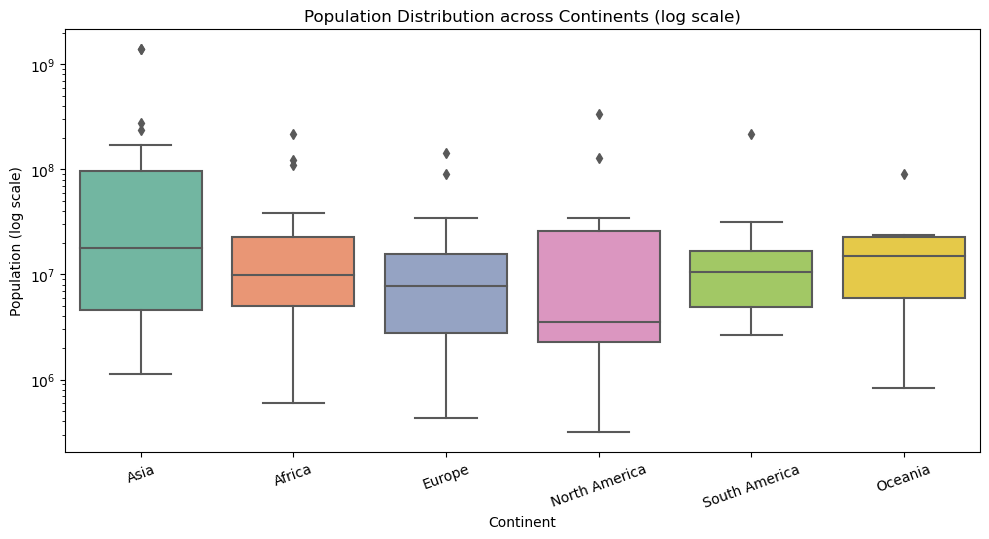


[6] Median population per continent:
continent
Africa            9827443
Asia             17722927
Europe            7702353
North America     3544528
Oceania          14897771
South America    10604081


In [7]:
# 4a.6 distribution of population across continents (boxplot)

plt.figure(figsize=(10, 5.5))

sns.boxplot(
    data=df,
    x="continent",
    y="population",
    palette="Set2"
)

plt.yscale("log")   # population is highly skewed

plt.title("Population Distribution across Continents (log scale)")
plt.xlabel("Continent")
plt.ylabel("Population (log scale)")

plt.xticks(rotation=20)
plt.tight_layout()

plt.show()

print("\n[6] Median population per continent:")
print(df.groupby("continent")["population"].median().astype(int).to_string())

In [8]:
# 4a.7  categorize countries by life expectancy (apply -> new column)
def life_category(le):
    if le < 60:
        return "Low"
    elif le < 75:
        return "Medium"
    return "High"
df["life_category"] = df["life_expectancy"].apply(life_category)
print("\n[7] life_category counts:")
print(df["life_category"].value_counts().to_string())


[7] life_category counts:
Medium    60
High      52
Low        6


In [9]:
# 4a.8  average population per continent where AVERAGE life expectancy > 75
cont_life = df.groupby("continent")["life_expectancy"].mean()
healthy = cont_life[cont_life > 75].index                      # continents passing the test
avg_pop = df[df["continent"].isin(healthy)].groupby("continent")["population"].mean()
print("\n[8] Continents with avg life-exp > 75:", list(healthy))
print("    Their average population:")
print(avg_pop.astype(int).to_string())


[8] Continents with avg life-exp > 75: ['Europe', 'North America', 'Oceania']
    Their average population:
continent
Europe           17625748
North America    43308129
Oceania          22171997


In [13]:
# ============================================================================
print("\n" + "=" * 70)
print("QUESTION 4b  -  ADULT (CENSUS INCOME) DATASET")
print("=" * 70)
ad = pd.read_csv("adult.csv")
print("shape:", ad.shape)

# 4b.1  proportion of German citizens
german = (ad["native-country"] == "Germany").mean()
print("\n[1] Proportion of German citizens:", round(german * 100, 2), "%")


QUESTION 4b  -  ADULT (CENSUS INCOME) DATASET
shape: (5000, 15)

[1] Proportion of German citizens: 1.36 %



[2] Most common occupation: Prof-specialty (690)


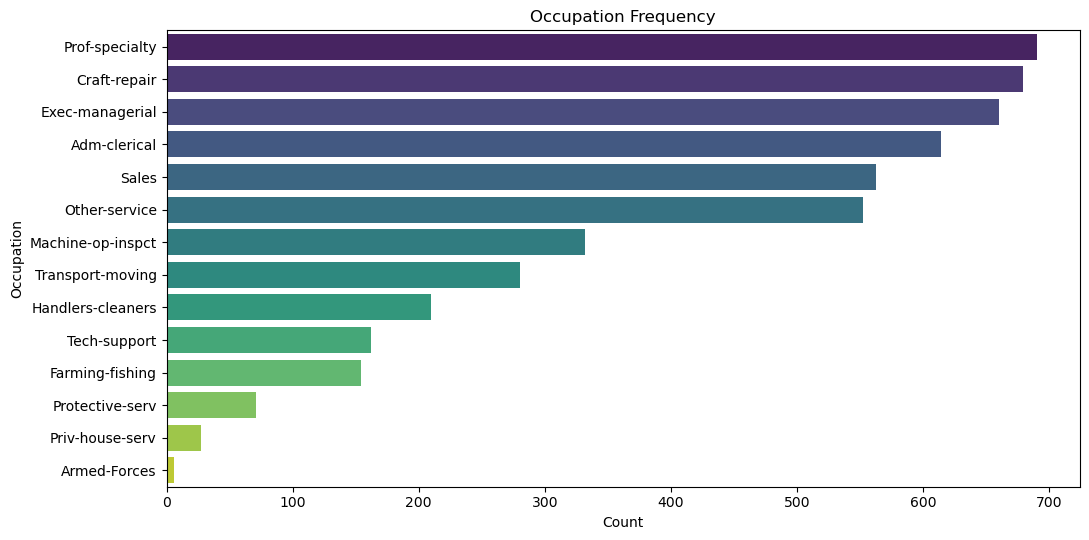

In [14]:
# 4b.2 most common occupation (+ graph)

occ = ad["occupation"].value_counts()

print("\n[2] Most common occupation:", occ.idxmax(), f"({occ.max()})")

plt.figure(figsize=(11, 5.5))

sns.countplot(
    data=ad,
    y="occupation",
    order=occ.index,
    palette="viridis"
)

plt.title("Occupation Frequency")
plt.xlabel("Count")
plt.ylabel("Occupation")

plt.tight_layout()
plt.show()

In [15]:
# 4b.3  mean & std of age by salary group
print("\n[3] Age by salary group:")
print(ad.groupby("salary")["age"].agg(["mean", "std"]).round(2).to_string())



[3] Age by salary group:
         mean    std
salary              
<=50K   37.77  12.00
>50K    42.55  12.77


In [16]:
# 4b.4  do >50K earners have at least higher / HS education?
higher_edu = ["Bachelors", "Prof-school", "Assoc-acdm", "Assoc-voc",
              "Masters", "Doctorate"]
rich = ad[ad["salary"] == ">50K"]
prop_higher = rich["education"].isin(higher_edu).mean()
at_least_hs = ["HS-grad", "Some-college"] + higher_edu
prop_hs = rich["education"].isin(at_least_hs).mean()
print("\n[4] Among >50K earners:")
print("    with listed higher education :", round(prop_higher * 100, 2), "%")
print("    with at least HS education   :", round(prop_hs * 100, 2), "%")
print("    => 'all have higher education' is", prop_higher == 1.0)



[4] Among >50K earners:
    with listed higher education : 50.84 %
    with at least HS education   : 96.56 %
    => 'all have higher education' is False


In [17]:
# 4b.5  >50K proportion: married men vs single men
men = ad[ad["sex"] == "Male"].copy()
men["is_married"] = men["marital-status"].str.startswith("Married")
rate = men.groupby("is_married")["salary"].apply(lambda s: (s == ">50K").mean())
print("\n[5] >50K proportion among men:")
print("    married men:", round(rate.get(True, 0) * 100, 2), "%")
print("    single  men:", round(rate.get(False, 0) * 100, 2), "%")



[5] >50K proportion among men:
    married men: 41.05 %
    single  men: 14.51 %


In [18]:
# 4b.6  max hours-per-week; how many work it; % earning >50K among them
max_h = ad["hours-per-week"].max()
at_max = ad[ad["hours-per-week"] == max_h]
pct_rich_at_max = (at_max["salary"] == ">50K").mean() * 100
print("\n[6] Max hours-per-week:", max_h, "| people working it:", len(at_max),
      "| % earning >50K:", round(pct_rich_at_max, 2), "%")


[6] Max hours-per-week: 99 | people working it: 12 | % earning >50K: 50.0 %


In [19]:
# 4b.7  average hours-per-week by salary, per native-country (first few rows)
hpw = ad.groupby(["native-country", "salary"])["hours-per-week"].mean().round(1)
hpw_tab = hpw.unstack()
print("\n[7] Avg hours-per-week by country x salary (first 6 countries):")
print(hpw_tab.head(6).to_string())



[7] Avg hours-per-week by country x salary (first 6 countries):
salary          <=50K  >50K
native-country             
Canada           39.9  42.6
China            40.9  43.0
Cuba             39.3  37.6
England          33.3  43.2
Germany          41.5  46.9
India            39.1  51.1
